In [40]:
import wfdb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib

## MIT-BIH Arrhythmia Database

### Arrhythmia Database contains 48 half-hour excerpts of two-channel ambulatory ECG recordings

In [41]:
records_folder = pathlib.Path('../data/physionet.org/files/mitdb/1.0.0')

In [42]:
def get_available_pacients(path):
    ids = set()
    for subject in os.listdir(path):
        if os.path.isfile(os.path.join(path, subject)):
            id, _ = os.path.splitext(subject)
            if len(id) == 3:
                ids.add(id)
    return sorted(ids)

### Informações dos pacientes

In [43]:
def read_subject_info(subject):
    data_path = str(records_folder/subject)
    header = wfdb.rdheader(data_path)

    comments = header.comments[0].split(' ')
    age = int(comments[0])
    gender = comments[1]

    medicine = header.comments[1]

    return [subject, age, gender, medicine]

In [44]:
data = []
for pacient in get_available_pacients(records_folder):
    data.append(read_subject_info(pacient))

df = pd.DataFrame(data, columns=['ID', 'Idade', 'Gênero', 'Medicamentos'])
df.head()


,ID,Idade,Gênero,Medicamentos
0,100,69,M,"Aldomet, Inderal"
1,101,75,F,Diapres
2,102,84,F,Digoxin
3,103,-1,M,"Diapres, Xyloprim"
4,104,66,F,"Digoxin, Pronestyl"


#### Distribuições

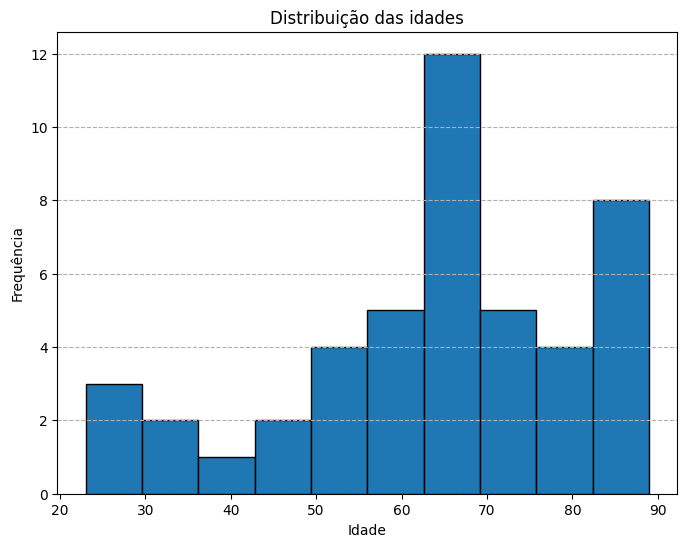

In [45]:
valid_ages = (df['Idade'][df['Idade'] != -1])

plt.figure(figsize=(8,6))
plt.hist(valid_ages, edgecolor="black")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição das idades")
plt.grid(linestyle='--', axis='y')
plt.show()


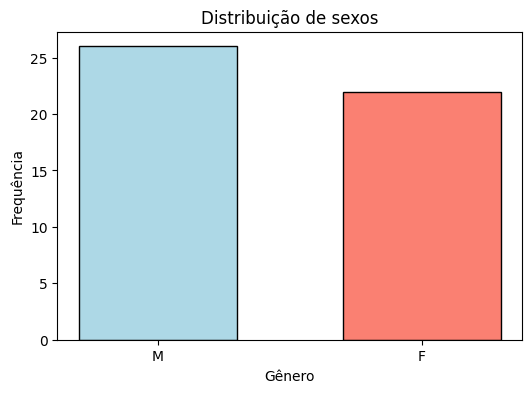

In [46]:
gender_count = df["Gênero"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    gender_count.index, 
    gender_count.values, 
    edgecolor='black', 
    color=['lightblue', 'salmon'],
    width=0.6)
plt.xlabel('Gênero')
plt.ylabel('Frequência')
plt.title("Distribuição de sexos")
plt.show()


### Leitura dos dados

In [47]:
def read_subject_signal(subject):
    data_path = str(records_folder/subject)
    record = wfdb.rdrecord(data_path)

    signal = record.p_signal
    fs = record.fs

    return signal, fs

In [48]:
def read_subject_annotation(subject):
    data_path = str(records_folder/subject)
    annotation =  wfdb.rdann(data_path, 'atr')

    return annotation

In [49]:
def read_subject_data(subject):
    
    signal, fs = read_subject_signal(subject)
    annotation = read_subject_annotation(subject)

    print('Signal shape:', signal.shape)
    print('Signal frequency: ', fs)
    print('number of annotated beats: ', len(annotation.sample))

    return signal, fs, annotation

#### Data sample

In [50]:
available_pacients = get_available_pacients(records_folder)

subject = available_pacients[0]
signal, fs, annotation = read_subject_data(subject)

signal_channel_1 = signal[:, 0]
signal_channel_2 = signal[:, 1]

Signal shape: (650000, 2)
Signal frequency:  360
number of annotated beats:  2274


In [51]:
print(annotation.sample[:10])
print(annotation.symbol[:10])

print(set(annotation.symbol))

[  18   77  370  662  946 1231 1515 1809 2044 2402]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']
{'+', 'A', 'V', 'N'}


In [ ]:
arrythm_times = []
ventricular_times = []
normal_times = []

for sample, symbol in zip(annotation.sample, annotation.symbol):
    time = sample/fs
    tuple_member = (time, symbol)
    if symbol == 'A':
        arrythm_times.append(tuple_member)
    if symbol == 'V':
        ventricular_times.append(tuple_member)
    if symbol == 'N':
        normal_times.append(tuple_member)